# ♿ Accessibility Checker

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/accessibility-checker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/accessibility-checker/demo.ipynb)

**Pain point:** *"We don't test for accessibility until the end."*

Paste HTML, get WCAG-referenced findings with severity levels and a 0-100 score — pure stdlib parsing, runs anywhere.

**What this notebook covers:**
1. The rule engine — one parser pass, 13 automated WCAG checks
2. Scanning a page with 12 planted issues
3. Scoring and severity weighting
4. Visualizing the findings
5. Confirming a clean page passes
6. Try your own HTML


## Step 1 — The rule engine

A single `HTMLParser` pass collects everything the rules need (images, links, buttons, form controls, headings, labels, tabindex, inline handlers). Then 13 checks fire, each mapped to a WCAG success criterion:

| Check | Severity | WCAG |
|---|---|---|
| Image without `alt` | critical | 1.1.1 |
| Placeholder alt text ("image") | moderate | 1.1.1 |
| Link/button with no accessible name | critical | 2.4.4 / 4.1.2 |
| Vague link text ("click here") | moderate | 2.4.4 |
| Form control without label | critical | 3.3.2 |
| Missing `lang` / `<title>` | serious | 3.1.1 / 2.4.2 |
| Heading level skips, missing/multiple h1 | moderate | 1.3.1 |
| Positive `tabindex` | serious | 2.4.3 |
| Click handler on non-interactive element | serious | 2.1.1 |
| Missing viewport meta | moderate | 1.4.10 |

Score = 100 minus severity-weighted penalties (critical 10, serious 6, moderate 3, minor 1).


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from html.parser import HTMLParser
from typing import Dict, List, Optional, Tuple

VAGUE_LINK_TEXT = {"click here", "here", "read more", "more", "link", "this", "learn more"}
SEVERITY_WEIGHT = {"critical": 10, "serious": 6, "moderate": 3, "minor": 1}


@dataclass
class Finding:
    rule: str
    severity: str  # critical | serious | moderate | minor
    element: str
    message: str
    wcag: str


@dataclass
class _Element:
    tag: str
    attrs: Dict[str, Optional[str]]
    text: str = ""


class _Collector(HTMLParser):
    """Single pass over the document, collecting everything the rules need."""

    def __init__(self) -> None:
        super().__init__(convert_charrefs=True)
        self.images: List[_Element] = []
        self.links: List[_Element] = []
        self.buttons: List[_Element] = []
        self.inputs: List[_Element] = []
        self.headings: List[Tuple[int, str]] = []
        self.label_targets: set = set()
        self.has_html_lang = False
        self.has_title = False
        self.has_viewport = False
        self.positive_tabindex: List[str] = []
        self.inline_event_handlers: List[str] = []
        self._stack: List[_Element] = []

    def handle_starttag(self, tag: str, attrs_list) -> None:
        attrs = dict(attrs_list)
        el = _Element(tag=tag, attrs=attrs)
        if tag == "html" and attrs.get("lang", "").strip():
            self.has_html_lang = True
        elif tag == "title":
            self.has_title = True
        elif tag == "meta" and attrs.get("name", "").lower() == "viewport":
            self.has_viewport = True
        elif tag == "img":
            self.images.append(el)
        elif tag == "a":
            self._stack.append(el)
        elif tag == "button":
            self._stack.append(el)
        elif tag in ("input", "select", "textarea"):
            self.inputs.append(el)
        elif tag == "label" and attrs.get("for"):
            self.label_targets.add(attrs["for"])
        elif tag in ("h1", "h2", "h3", "h4", "h5", "h6"):
            self._stack.append(el)
        tabindex = attrs.get("tabindex")
        if tabindex and tabindex.lstrip("+").isdigit() and int(tabindex) > 0:
            self.positive_tabindex.append(f"<{tag} tabindex={tabindex}>")
        if any(k.startswith("on") for k in attrs) and tag not in ("button", "a", "input", "select", "textarea", "form"):
            self.inline_event_handlers.append(f"<{tag}>")

    def handle_data(self, data: str) -> None:
        if self._stack:
            self._stack[-1].text += data

    def handle_endtag(self, tag: str) -> None:
        if self._stack and self._stack[-1].tag == tag:
            el = self._stack.pop()
            if tag == "a":
                self.links.append(el)
            elif tag == "button":
                self.buttons.append(el)
            else:
                self.headings.append((int(tag[1]), el.text.strip()))


def _describe(el: _Element, limit: int = 60) -> str:
    attrs = " ".join(f'{k}="{v}"' for k, v in list(el.attrs.items())[:3] if v is not None)
    return f"<{el.tag}{' ' + attrs if attrs else ''}>"[:limit]


def check_html(html: str) -> List[Finding]:
    c = _Collector()
    c.feed(html)
    findings: List[Finding] = []

    if not c.has_html_lang:
        findings.append(Finding("html-lang", "serious", "<html>",
                                "Missing lang attribute — screen readers can't pick the right voice", "WCAG 3.1.1"))
    if not c.has_title:
        findings.append(Finding("page-title", "serious", "<head>",
                                "Missing <title> — the page has no accessible name", "WCAG 2.4.2"))
    if not c.has_viewport:
        findings.append(Finding("viewport", "moderate", "<head>",
                                "Missing viewport meta — pinch-zoom users and mobile readers suffer", "WCAG 1.4.10"))

    for img in c.images:
        if "alt" not in img.attrs:
            findings.append(Finding("img-alt", "critical", _describe(img),
                                    "Image has no alt attribute — invisible to screen readers", "WCAG 1.1.1"))
        elif img.attrs.get("alt", "").strip().lower() in ("image", "photo", "picture", "img"):
            findings.append(Finding("img-alt-vague", "moderate", _describe(img),
                                    "Alt text is a placeholder word — describe what the image shows", "WCAG 1.1.1"))

    for a in c.links:
        text = a.text.strip().lower()
        if not text and not a.attrs.get("aria-label"):
            findings.append(Finding("link-name", "critical", _describe(a),
                                    "Link has no text or aria-label — announced as just 'link'", "WCAG 2.4.4"))
        elif text in VAGUE_LINK_TEXT:
            findings.append(Finding("link-vague", "moderate", _describe(a),
                                    f"Link text '{a.text.strip()}' is meaningless out of context", "WCAG 2.4.4"))

    for b in c.buttons:
        if not b.text.strip() and not b.attrs.get("aria-label"):
            findings.append(Finding("button-name", "critical", _describe(b),
                                    "Button has no text or aria-label", "WCAG 4.1.2"))

    for inp in c.inputs:
        if inp.attrs.get("type") in ("hidden", "submit", "button"):
            continue
        has_label = (inp.attrs.get("id") in c.label_targets or inp.attrs.get("aria-label")
                     or inp.attrs.get("aria-labelledby"))
        if not has_label:
            findings.append(Finding("input-label", "critical", _describe(inp),
                                    "Form control has no label — users don't know what to enter", "WCAG 3.3.2"))

    last_level = 0
    h1_count = 0
    for level, text in c.headings:
        if level == 1:
            h1_count += 1
        if last_level and level > last_level + 1:
            findings.append(Finding("heading-skip", "moderate", f"<h{level}> '{text[:40]}'",
                                    f"Heading jumps from h{last_level} to h{level} — outline breaks", "WCAG 1.3.1"))
        last_level = level
    if h1_count == 0 and c.headings:
        findings.append(Finding("no-h1", "moderate", "<body>",
                                "No <h1> — the page has no top-level heading", "WCAG 1.3.1"))
    if h1_count > 1:
        findings.append(Finding("multi-h1", "minor", "<body>",
                                f"{h1_count} <h1> elements — keep one main heading", "WCAG 1.3.1"))

    for el in c.positive_tabindex:
        findings.append(Finding("tabindex", "serious", el,
                                "Positive tabindex hijacks natural tab order", "WCAG 2.4.3"))
    for el in c.inline_event_handlers:
        findings.append(Finding("click-div", "serious", el,
                                "Event handler on a non-interactive element — keyboard users can't reach it",
                                "WCAG 2.1.1"))
    return findings


def score(findings: List[Finding]) -> int:
    penalty = sum(SEVERITY_WEIGHT[f.severity] for f in findings)
    return max(0, 100 - penalty)


def grade(value: int) -> str:
    return "A" if value >= 90 else "B" if value >= 75 else "C" if value >= 60 else "D" if value >= 40 else "F"


def report_markdown(findings: List[Finding]) -> str:
    s = score(findings)
    lines = [f"# Accessibility Report — score {s}/100 (grade {grade(s)})\n"]
    if not findings:
        lines.append("No issues detected by automated checks. Manual testing still required.")
    for sev in ("critical", "serious", "moderate", "minor"):
        group = [f for f in findings if f.severity == sev]
        if group:
            lines.append(f"\n## {sev.capitalize()} ({len(group)})")
            for f in group:
                lines.append(f"- **{f.rule}** [{f.wcag}] `{f.element}` — {f.message}")
    lines.append("\n---\n*Automated checks catch ~30-40% of WCAG issues. Pair with keyboard and screen-reader testing.*")
    return "\n".join(lines)


## Step 2 — Scan a page with planted issues

A small product page with 12 classic accessibility mistakes — the kind that ship every day.

In [2]:
BAD_PAGE = """<html>
<head><meta charset="utf-8"></head>
<body>
  <h1>Product Page</h1>
  <h4>Details</h4>
  <img src="hero.png">
  <img src="logo.png" alt="image">
  <a href="/buy">click here</a>
  <a href="/spec"></a>
  <div onclick="openMenu()">Menu</div>
  <form>
    <input type="text" name="email">
    <button></button>
  </form>
  <p tabindex="3">Featured</p>
</body>
</html>"""

findings = check_html(BAD_PAGE)
s = score(findings)
print(f"Score: {s}/100  (grade {grade(s)})  —  {len(findings)} findings\n")
for f in findings:
    print(f"  [{f.severity:8s}] {f.rule:14s} {f.wcag:11s} {f.element}")

Score: 24/100  (grade F)  —  12 findings

  [serious ] html-lang      WCAG 3.1.1  <html>
  [serious ] page-title     WCAG 2.4.2  <head>
  [moderate] viewport       WCAG 1.4.10 <head>
  [critical] img-alt        WCAG 1.1.1  <img src="hero.png">
  [moderate] img-alt-vague  WCAG 1.1.1  <img src="logo.png" alt="image">
  [moderate] link-vague     WCAG 2.4.4  <a href="/buy">
  [critical] link-name      WCAG 2.4.4  <a href="/spec">
  [critical] button-name    WCAG 4.1.2  <button>
  [critical] input-label    WCAG 3.3.2  <input type="text" name="email">
  [moderate] heading-skip   WCAG 1.3.1  <h4> 'Details'
  [serious ] tabindex       WCAG 2.4.3  <p tabindex=3>
  [serious ] click-div      WCAG 2.1.1  <div>


## Step 3 — The report

The same findings as a Markdown report, grouped by severity — ready to paste into a PR comment or ticket.

In [3]:
print(report_markdown(findings)[:900])

# Accessibility Report — score 24/100 (grade F)


## Critical (4)
- **img-alt** [WCAG 1.1.1] `<img src="hero.png">` — Image has no alt attribute — invisible to screen readers
- **link-name** [WCAG 2.4.4] `<a href="/spec">` — Link has no text or aria-label — announced as just 'link'
- **button-name** [WCAG 4.1.2] `<button>` — Button has no text or aria-label
- **input-label** [WCAG 3.3.2] `<input type="text" name="email">` — Form control has no label — users don't know what to enter

## Serious (4)
- **html-lang** [WCAG 3.1.1] `<html>` — Missing lang attribute — screen readers can't pick the right voice
- **page-title** [WCAG 2.4.2] `<head>` — Missing <title> — the page has no accessible name
- **tabindex** [WCAG 2.4.3] `<p tabindex=3>` — Positive tabindex hijacks natural tab order
- **click-div** [WCAG 2.1.1] `<div>` — Event handler on a non-interactive element — keyboard users can't rea


## Step 4 — Visualize findings by severity and WCAG criterion

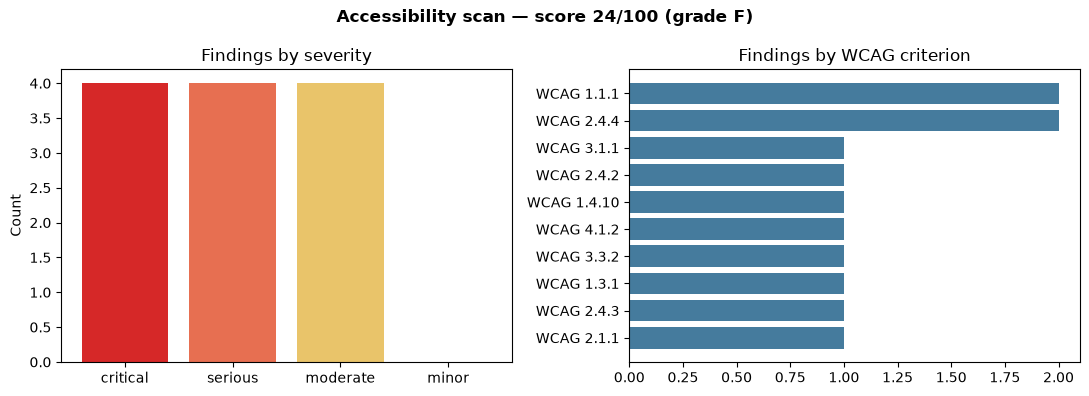

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

sev_order = ["critical", "serious", "moderate", "minor"]
sev_counts = Counter(f.severity for f in findings)
wcag_counts = Counter(f.wcag for f in findings)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
colors = {"critical": "#d62828", "serious": "#e76f51", "moderate": "#e9c46a", "minor": "#8ecae6"}
ax1.bar(sev_order, [sev_counts.get(x, 0) for x in sev_order], color=[colors[x] for x in sev_order])
ax1.set_title("Findings by severity")
ax1.set_ylabel("Count")

wcag_sorted = sorted(wcag_counts.items(), key=lambda kv: -kv[1])
ax2.barh([k for k, _ in wcag_sorted], [v for _, v in wcag_sorted], color="#457b9d")
ax2.set_title("Findings by WCAG criterion")
ax2.invert_yaxis()

fig.suptitle(f"Accessibility scan — score {s}/100 (grade {grade(s)})", fontweight="bold")
fig.tight_layout()
fig.savefig("a11y_findings.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — A clean page passes

Same checks, fixed markup: `lang`, `<title>`, viewport, real alt text, labeled input, named button, descriptive link.

In [5]:
CLEAN_PAGE = """<html lang="en">
<head><title>Good page</title><meta name="viewport" content="width=device-width"></head>
<body>
  <h1>Title</h1><h2>Section</h2>
  <img src="a.png" alt="Team photo at launch">
  <a href="/pricing">See pricing plans</a>
  <form><label for="em">Email</label><input id="em" type="text"><button>Subscribe</button></form>
</body>
</html>"""

clean_findings = check_html(CLEAN_PAGE)
print(f"Clean page: {len(clean_findings)} findings → score {score(clean_findings)}/100 (grade {grade(score(clean_findings))})")

Clean page: 0 findings → score 100/100 (grade A)


## Summary

| Page | Findings | Score | Grade |
|---|---|---|---|
| Planted-issues page | 12 | 24/100 | F |
| Fixed page | 0 | 100/100 | A |

The checker shifts accessibility left: instead of an audit at the end, every PR can carry a score. Automated checks catch roughly a third of WCAG issues — keyboard and screen-reader testing still matter, but nobody ships an unlabeled form field again.


## Try your own

Uncomment and paste your HTML:

In [6]:
# my_html = """
# <html><body>
#   <img src="banner.jpg">
#   <a href="/about">read more</a>
# </body></html>
# """
# fs = check_html(my_html)
# print(f"Score: {score(fs)}/100 ({grade(score(fs))})")
# for f in fs:
#     print(f"  [{f.severity}] {f.message}  ({f.wcag})")

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — 60 mini AI products in 6 months.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
